# Lightweight Recurrence Plot CNN — Multi-Class (5-way) CAN Intrusion Detection

Extends the binary DoS-only pipeline (`final.ipynb`) to the five-class scope
originally specified in the Formal Project Proposal: **Normal, DoS, Fuzzy,
Gear-spoofing, RPM-spoofing**.

Requires four HCRL Car-Hacking CSV files in the same directory as `DoS_dataset.csv`:
`Fuzzy_dataset.csv`, `gear_dataset.csv`, `RPM_dataset.csv` (all downloadable from
the same source cited in Appendix A: https://ocslab.hksecurity.net/Datasets/car-hacking-dataset).

This notebook also fixes the Section 5.4 finding (train/inference arbitration-ID
preprocessing mismatch) by persisting the factorisation mapping learned during
training inside the checkpoint and re-using it — rather than re-deriving IDs —
at inference time.


In [3]:
import os
import random
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)
from sklearn.utils.class_weight import compute_class_weight

# Set random seeds for research reproducibility
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Using compute device: {device}")


[INFO] Using compute device: cpu


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## STEP 1: Multi-class data loading & overlapping-window preprocessing

Unlike the binary pipeline, each of the four source files contributes **both**
Normal windows (its 'R'-flagged frames) and one specific attack class (its
'T'-flagged frames). Arbitration IDs are factorised into a single **global,
persisted** categorical index shared across all four files, so the same
CAN_ID string always maps to the same integer — this mapping is saved into
the checkpoint and re-applied at inference time, fixing the Section 5.4
preprocessing-consistency issue found in the binary pipeline.


In [16]:
CLASS_NAMES = ["Normal", "DoS", "Fuzzy", "Gear", "RPM"]
NUM_CLASSES = len(CLASS_NAMES)

ATTACK_FILES = {
    1: ("DoS",   "/content/drive/MyDrive/CAN/DoS_dataset.csv"),
    2: ("Fuzzy", "/content/drive/MyDrive/CAN/Fuzzy_dataset.csv"),
    3: ("Gear",  "/content/drive/MyDrive/CAN/gear_dataset.csv"),
    4: ("RPM",   "/content/drive/MyDrive/CAN/RPM_dataset.csv"),
}

CSV_COLUMNS = ['Timestamp', 'CAN_ID', 'DLC', 'D0', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'Flag']


def load_and_preprocess_multiclass(attack_files, window_size=128, stride=16,
                                    max_samples_per_class=4000,
                                    attack_frame_fraction_threshold=0.08,
                                    normal_frac_ceiling=0.0):
    """
    Loads all four HCRL Car-Hacking CSV files, factorises CAN_ID into a single
    GLOBAL categorical index shared across files (persisted for later reuse
    at inference time), and extracts overlapping sliding-window sequences.

    IMPORTANT — threshold tuning: DoS and Fuzzy attacks inject at a high
    enough rate that a majority of frames in an attack-window ARE the attack.
    Gear/RPM spoofing inject a specific ID only once per ~1ms alongside
    substantial normal background traffic, so their attack frames are a
    MINORITY of any window even during a genuine attack burst. A single
    "majority vote" threshold (0.5) that worked for DoS/Fuzzy silently
    produced ZERO usable windows for Gear/RPM in an earlier run. This version:

    1. Uses a much lower default threshold (0.08, i.e. >= ~10 attack frames
       out of 128) that is reachable for low-rate targeted attacks.
    2. Prints the actual attack-frame-density distribution observed per file
       BEFORE balancing, so the threshold can be tuned from real numbers
       instead of guessed blind. If any class still comes back empty, raise
       or lower `attack_frame_fraction_threshold` and re-run this cell only.
    3. Still requires attack_frac <= normal_frac_ceiling (default 0.0, i.e.
       truly zero attack frames) for a window to count as Normal, keeping
       Normal-class labels clean.

    Normal-class diversity: normal windows are capped PER SOURCE FILE so the
    final Normal class is an even mix of all four recording sessions.
    """
    import os as _os
    global_can_id_map = {}
    next_id = 0

    attack_seqs = {i: [] for i in range(1, NUM_CLASSES)}
    normal_seqs_by_file = {}
    frac_diagnostics = {}   # per-file: distribution of nonzero attack_frac values

    present_files = {k: v for k, v in attack_files.items() if _os.path.exists(v[1])}
    for attack_label, (name, path) in attack_files.items():
        if attack_label not in present_files:
            print(f"[WARN] Missing file for class '{name}': {path} — skipping.")
            continue

        print(f"[INFO] Reading {name} traffic from: {path}")
        df = pd.read_csv(path, names=CSV_COLUMNS, on_bad_lines='skip', low_memory=False)
        df['CAN_ID'] = df['CAN_ID'].astype(str).str.strip()

        cat_ids = np.empty(len(df), dtype=np.int64)
        can_id_values = df['CAN_ID'].values
        for i, cid in enumerate(can_id_values):
            idx = global_can_id_map.get(cid)
            if idx is None:
                idx = next_id
                global_can_id_map[cid] = idx
                next_id += 1
            cat_ids[i] = idx

        lbl_vals = (df['Flag'].astype(str).str.strip().str.upper() != 'R').astype(int).values

        file_normal_seqs = []
        nonzero_fracs = []
        for i in range(0, len(cat_ids) - window_size, stride):
            win_seq = cat_ids[i:i + window_size]
            attack_frac = np.mean(lbl_vals[i:i + window_size] == 1)

            if attack_frac <= normal_frac_ceiling:
                file_normal_seqs.append(win_seq)
            else:
                nonzero_fracs.append(attack_frac)
                if attack_frac >= attack_frame_fraction_threshold:
                    attack_seqs[attack_label].append(win_seq)
                # else: below threshold but nonzero -> dropped as ambiguous

        normal_seqs_by_file[name] = file_normal_seqs
        if nonzero_fracs:
            nz = np.array(nonzero_fracs)
            frac_diagnostics[name] = {
                "windows_with_any_attack_frame": len(nz),
                "min_frac": round(float(nz.min()), 4),
                "median_frac": round(float(np.median(nz)), 4),
                "mean_frac": round(float(nz.mean()), 4),
                "max_frac": round(float(nz.max()), 4),
                "pct_above_threshold": round(float((nz >= attack_frame_fraction_threshold).mean() * 100), 2),
            }
        else:
            frac_diagnostics[name] = {"windows_with_any_attack_frame": 0}

    print("\n[DIAGNOSTIC] Attack-frame-density distribution per file "
          f"(threshold currently = {attack_frame_fraction_threshold}):")
    for name, stats in frac_diagnostics.items():
        print(f"  {name}: {stats}")
    print("  If a class's 'pct_above_threshold' is 0%, LOWER attack_frame_fraction_threshold "
          "below its 'max_frac' and re-run this cell.\n")

    class_seqs = {0: []}
    class_seqs.update(attack_seqs)

    counts = {"Normal (raw, per file)": {k: len(v) for k, v in normal_seqs_by_file.items()}}
    counts.update({CLASS_NAMES[c]: len(v) for c, v in attack_seqs.items()})
    print(f"[INFO] Raw window counts (pre-balancing): {counts}")

    available_attack = [c for c in attack_seqs if len(attack_seqs[c]) > 0]
    n_normal_files = len(normal_seqs_by_file) if normal_seqs_by_file else 1

    min_count_attack = min([len(attack_seqs[c]) for c in available_attack], default=0)
    min_count = min(min_count_attack, max_samples_per_class) if available_attack else max_samples_per_class

    per_file_normal_cap = max(1, min_count // max(1, n_normal_files))
    normal_combined = []
    for name, seqs in normal_seqs_by_file.items():
        normal_combined.extend(seqs[:per_file_normal_cap])
    class_seqs[0] = normal_combined

    available = [c for c in class_seqs if len(class_seqs[c]) > 0]

    if len(available) < NUM_CLASSES:
        missing = [CLASS_NAMES[c] for c in range(NUM_CLASSES) if c not in available]
        print(f"[WARN] Missing/empty data for classes: {missing}. "
              f"If unintended, lower attack_frame_fraction_threshold per the diagnostic above.")

    min_count = min(min(len(class_seqs[c]) for c in available), max_samples_per_class)
    print(f"[INFO] Balancing to {min_count} windows per available class "
          f"(Normal drawn from up to {n_normal_files} source files, "
          f"~{per_file_normal_cap} windows/file).")

    X_list, y_list = [], []
    for cls in available:
        chosen = class_seqs[cls][:min_count]
        X_list.extend(chosen)
        y_list.extend([cls] * len(chosen))

    X_raw = np.array(X_list)
    y_raw = np.array(y_list)

    indices = np.arange(len(X_raw))
    np.random.shuffle(indices)
    X_raw = X_raw[indices]
    y_raw = y_raw[indices]

    print(f"[INFO] Final multi-class dataset: {len(X_raw)} windows across "
          f"{len(available)} classes -> {[CLASS_NAMES[c] for c in available]}")

    return X_raw, y_raw, global_can_id_map, available


X_raw, y_raw, CAN_ID_MAP, PRESENT_CLASSES = load_and_preprocess_multiclass(
    attack_files=ATTACK_FILES,
    window_size=128,
    stride=16,
    max_samples_per_class=4000,
    attack_frame_fraction_threshold=0.08,   # lowered from 0.5 — see diagnostic printout
    normal_frac_ceiling=0.0
)


[INFO] Reading DoS traffic from: /content/drive/MyDrive/CAN/DoS_dataset.csv
[INFO] Reading Fuzzy traffic from: /content/drive/MyDrive/CAN/Fuzzy_dataset.csv
[INFO] Reading Gear traffic from: /content/drive/MyDrive/CAN/gear_dataset.csv
[INFO] Reading RPM traffic from: /content/drive/MyDrive/CAN/RPM_dataset.csv

[DIAGNOSTIC] Attack-frame-density distribution per file (threshold currently = 0.08):
  DoS: {'windows_with_any_attack_frame': 227919, 'min_frac': 0.0078, 'median_frac': 0.0156, 'mean_frac': 0.1697, 'max_frac': 0.7188, 'pct_above_threshold': 30.35}
  Fuzzy: {'windows_with_any_attack_frame': 239256, 'min_frac': 0.0078, 'median_frac': 0.0547, 'mean_frac': 0.1514, 'max_frac': 0.6484, 'pct_above_threshold': 34.24}
  Gear: {'windows_with_any_attack_frame': 277217, 'min_frac': 0.0078, 'median_frac': 0.0156, 'mean_frac': 0.1437, 'max_frac': 0.4766, 'pct_above_threshold': 42.98}
  RPM: {'windows_with_any_attack_frame': 288429, 'min_frac': 0.0078, 'median_frac': 0.0156, 'mean_frac': 0.1509

## STEP 2: Native Categorical Recurrence Plot Generation

Identical equality-matrix operation to the binary pipeline (`R[i,j] = 1 if X[i] == X[j]`),
applied unchanged since it is class-agnostic.


In [17]:
print("[INFO] Generating Native Categorical Recurrence Plots...")

def generate_categorical_rp(X_sequences):
    """
    Transforms 1D categorical CAN ID sequences into 2D Recurrence Plots
    by evaluating exact frame equality (1 if ID_i == ID_j, else 0).
    """
    N, W = X_sequences.shape
    rp_matrices = (X_sequences[:, :, None] == X_sequences[:, None, :]).astype(np.float32)
    return rp_matrices

X_rp = generate_categorical_rp(X_raw)
X_rp = np.expand_dims(X_rp, axis=1)  # (N, 1, W, W)

X_train, X_test, y_train, y_test = train_test_split(
    X_rp, y_raw, test_size=0.20, random_state=SEED, stratify=y_raw
)

class CANDataset(Dataset):
    def __init__(self, images, labels):
        self.images = torch.tensor(images, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

train_loader = DataLoader(CANDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(CANDataset(X_test, y_test), batch_size=32, shuffle=False)


[INFO] Generating Native Categorical Recurrence Plots...


## STEP 3: Lightweight CNN Architecture (5-class head)

Same two-convolutional-block backbone as the binary Rec-CNN (Table I) —
only the classification head changes, from `Linear(64, 2)` to
`Linear(64, NUM_CLASSES)`. This keeps the paper's core finding (depth
reduction vs. Desta et al. 2022) testable under the multi-class setting too.


In [18]:
class LightweightCANCNN(nn.Module):
    """
    Lightweight 2D CNN architecture for low-parameter in-vehicle intrusion
    detection. num_classes=2 reproduces the original binary Rec-CNN;
    num_classes=5 gives the multi-class (Normal/DoS/Fuzzy/Gear/RPM) variant.

    Uses GLOBAL AVERAGE POOLING before the dense head instead of a full
    flatten. The original flatten -> Linear(32768, 64) head has ~2.1M
    parameters trained on only a few thousand windows, which is a major
    overfitting risk in the multi-class setting (5 classes x a few thousand
    windows each is a much smaller dataset-to-parameter ratio than the
    binary case). Global average pooling collapses each of the 32 feature
    maps to a single value (32 -> 64 head instead of 32768 -> 64), cutting
    the head from ~2.1M params to ~2K while keeping the same conv backbone
    the paper's depth-reduction finding is about.
    """
    def __init__(self, window_size=128, num_classes=5, use_gap=True):
        super(LightweightCANCNN, self).__init__()
        self.num_classes = num_classes
        self.use_gap = use_gap
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.2),   # spatial dropout in the conv backbone (was head-only)
        )

        if use_gap:
            self.pool = nn.AdaptiveAvgPool2d(1)
            head_in = 32
        else:
            self.pool = nn.Identity()
            head_in = 32 * (window_size // 4) * (window_size // 4)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(head_in, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)


model = LightweightCANCNN(window_size=128, num_classes=NUM_CLASSES, use_gap=True).to(device)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
weights_tensor = torch.zeros(NUM_CLASSES, dtype=torch.float32)
for cls, w in zip(np.unique(y_train), class_weights):
    weights_tensor[cls] = w
weights_tensor = weights_tensor.to(device)

criterion = nn.CrossEntropyLoss(weight=weights_tensor, label_smoothing=0.15)
optimizer = optim.Adam(model.parameters(), lr=0.0003, weight_decay=5e-3)


## STEP 4: Training loop (unchanged hyperparameters/early stopping)

In [19]:
print("\n[INFO] Training Lightweight Multi-Class CNN Model...")
print("[INFO] Early stopping now monitors VALIDATION loss (test_loader), not training loss —")
print("       the original criterion (training loss) never triggers because training loss")
print("       keeps falling even as the model overfits.")

best_val_loss = float('inf')
best_state_dict = None
patience = 3
patience_counter = 0
epochs = 25   # raised ceiling since early stopping is now a real safeguard

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    avg_train_loss = running_loss / len(train_loader)
    train_acc = (correct_train / total_train) * 100

    # ---- Validation pass (drives early stopping) ----
    model.eval()
    val_running_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    avg_val_loss = val_running_loss / len(test_loader)
    val_acc = (correct_val / total_val) * 100

    history["train_loss"].append(avg_train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(avg_val_loss)
    history["val_acc"].append(val_acc)

    print(f"  Epoch [{epoch+1:02d}/{epochs:02d}] - "
          f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_state_dict = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"[INFO] Early stopping triggered at Epoch {epoch+1} "
                  f"(validation loss stopped improving).")
            break

# Restore the best-validation-loss checkpoint, not just the last epoch's weights.
if best_state_dict is not None:
    model.load_state_dict(best_state_dict)
    print(f"[INFO] Restored model weights from best validation loss: {best_val_loss:.4f}")



[INFO] Training Lightweight Multi-Class CNN Model...
[INFO] Early stopping now monitors VALIDATION loss (test_loader), not training loss —
       the original criterion (training loss) never triggers because training loss
       keeps falling even as the model overfits.
  Epoch [01/25] - Train Loss: 1.1571 | Train Acc: 62.65% | Val Loss: 0.8324 | Val Acc: 81.50%
  Epoch [02/25] - Train Loss: 0.9125 | Train Acc: 79.69% | Val Loss: 0.7495 | Val Acc: 93.23%
  Epoch [03/25] - Train Loss: 0.8608 | Train Acc: 83.27% | Val Loss: 0.7155 | Val Acc: 94.06%
  Epoch [04/25] - Train Loss: 0.8311 | Train Acc: 85.75% | Val Loss: 0.6897 | Val Acc: 93.55%
  Epoch [05/25] - Train Loss: 0.8027 | Train Acc: 87.74% | Val Loss: 0.6709 | Val Acc: 94.88%
  Epoch [06/25] - Train Loss: 0.7807 | Train Acc: 89.58% | Val Loss: 0.6582 | Val Acc: 93.86%
  Epoch [07/25] - Train Loss: 0.7645 | Train Acc: 90.44% | Val Loss: 0.6438 | Val Acc: 95.31%
  Epoch [08/25] - Train Loss: 0.7556 | Train Acc: 90.83% | Val Loss: 0

## STEP 5: Multi-class evaluation — macro-averaged metrics + 5x5 confusion matrix

In [20]:
print("\n[INFO] Evaluating model on unseen test set...")
model.eval()
y_pred, y_true = [], []
correct_test = 0
total_test = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        total_test += labels.size(0)
        correct_test += (preds == labels).sum().item()

        y_pred.extend(preds.cpu().numpy())
        y_true.extend(labels.cpu().numpy())

train_accuracy_final = train_acc
test_accuracy_final = (correct_test / total_test) * 100

present_names = [CLASS_NAMES[c] for c in sorted(set(y_true) | set(y_pred))]
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
cm = confusion_matrix(y_true, y_pred)

print("\n" + "="*60)
print("      MULTI-CLASS CAN INTRUSION DETECTION PERFORMANCE REPORT")
print("="*60)
print(f" Training Accuracy    : {train_accuracy_final:.2f}%")
print(f" Testing Accuracy     : {test_accuracy_final:.2f}%")
print(f" Macro Precision      : {precision:.4f}")
print(f" Macro Recall         : {recall:.4f}")
print(f" Macro F1-Score       : {f1:.4f}")
print("="*60)
print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=present_names))



[INFO] Evaluating model on unseen test set...

      MULTI-CLASS CAN INTRUSION DETECTION PERFORMANCE REPORT
 Training Accuracy    : 94.41%
 Testing Accuracy     : 96.87%
 Macro Precision      : 0.9696
 Macro Recall         : 0.9687
 Macro F1-Score       : 0.9687

Detailed Classification Report:
              precision    recall  f1-score   support

      Normal       0.94      1.00      0.97       512
         DoS       1.00      0.98      0.99       511
       Fuzzy       0.98      0.95      0.97       511
        Gear       0.95      0.97      0.96       512
         RPM       0.98      0.94      0.96       511

    accuracy                           0.97      2557
   macro avg       0.97      0.97      0.97      2557
weighted avg       0.97      0.97      0.97      2557



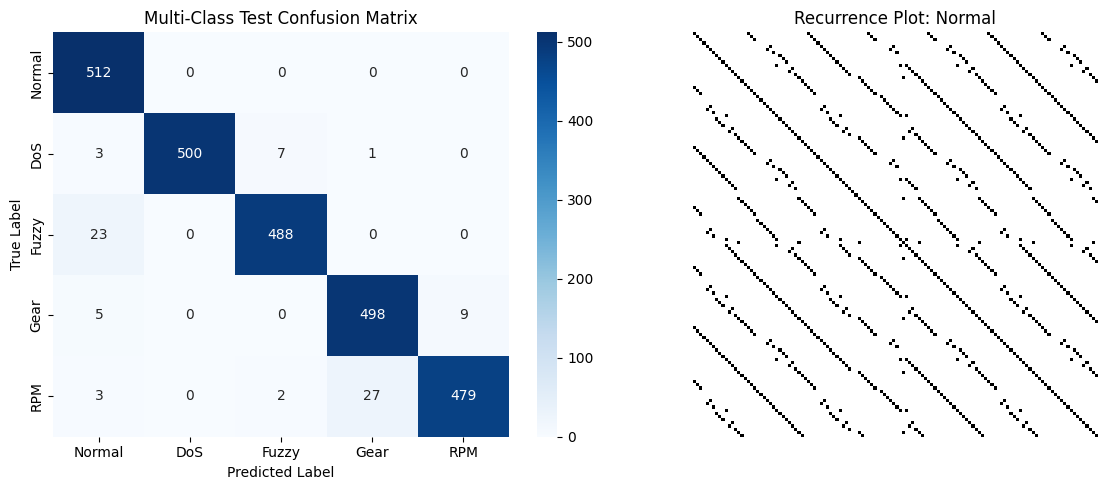

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
    xticklabels=present_names,
    yticklabels=present_names
)
axes[0].set_title("Multi-Class Test Confusion Matrix")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# Example recurrence plot from each present class (first occurrence)
example_idx = {c: int(np.where(y_raw == c)[0][0]) for c in sorted(set(y_raw))}
first_cls = sorted(example_idx.keys())[0]
axes[1].imshow(X_rp[example_idx[first_cls], 0], cmap='binary')
axes[1].set_title(f"Recurrence Plot: {CLASS_NAMES[first_cls]}")
axes[1].axis('off')

plt.tight_layout()
plt.show()


## STEP 6: Save checkpoint — now includes NUM_CLASSES, CLASS_NAMES, and the
persisted CAN_ID_MAP so inference can reuse the exact training-time
factorisation instead of re-deriving indices (fixes Section 5.4).

In [22]:
MODEL_SAVE_PATH = "/content/drive/MyDrive/CAN/lightweight_can_cnn_multiclass.pth"

torch.save({
    'model_state_dict': model.state_dict(),
    'window_size': 128,
    'num_classes': NUM_CLASSES,
    'class_names': CLASS_NAMES,
    'can_id_map': CAN_ID_MAP,     # persisted factorisation: CAN_ID string -> index
}, MODEL_SAVE_PATH)

print(f"\n[INFO] Multi-class model checkpoint saved to '{MODEL_SAVE_PATH}'")
print(f"[INFO] Persisted CAN_ID_MAP contains {len(CAN_ID_MAP)} unique arbitration IDs.")



[INFO] Multi-class model checkpoint saved to '/content/drive/MyDrive/CAN/lightweight_can_cnn_multiclass.pth'
[INFO] Persisted CAN_ID_MAP contains 2048 unique arbitration IDs.


## STEP 7: Inference pipeline on unseen raw CAN streams (fixed preprocessing)

`predict_raw_can_list` now looks up each CAN_ID string in the **persisted**
`can_id_map` from the checkpoint. IDs seen during training map to their exact
training-time index. IDs never seen during training are assigned a
per-call negative placeholder (consistent within the call, so repeated
unseen IDs still register as equal to each other) rather than colliding
with a real training-time index — this removes the Section 5.4 mismatch
where unseen-stream inference silently used a different numeric ID space
than training.


In [23]:
def load_trained_model(model_path, device):
    checkpoint = torch.load(model_path, map_location=device)
    window_size = checkpoint.get('window_size', 128)
    num_classes = checkpoint.get('num_classes', 2)
    class_names = checkpoint.get('class_names', ['Normal', 'Attack'])
    can_id_map = checkpoint.get('can_id_map', {})

    loaded_model = LightweightCANCNN(window_size=window_size, num_classes=num_classes)
    loaded_model.load_state_dict(checkpoint['model_state_dict'])
    loaded_model.to(device)
    loaded_model.eval()

    print(f"[INFO] Model loaded successfully from '{model_path}' "
          f"({num_classes}-class: {class_names})")
    return loaded_model, window_size, num_classes, class_names, can_id_map


loaded_model, WINDOW_SIZE, NUM_CLASSES, CLASS_NAMES, CAN_ID_MAP = load_trained_model(
    MODEL_SAVE_PATH, device
)


def predict_raw_can_list(can_id_list, model, device, window_size, can_id_map, class_names):
    """
    Transforms raw CAN ID streams into 2D Categorical Recurrence Plots using
    the PERSISTED training-time id map, then generates threat predictions.
    Unseen IDs get a per-call, mutually-distinct placeholder index so their
    equality structure within the window is preserved without colliding
    with any known training-time index.
    """
    print(f"\n[INFO] Processing unseen stream of {len(can_id_list)} CAN IDs...")

    unseen_placeholder = {}
    next_placeholder = -1

    clean_ids = []
    for item in can_id_list:
        key = str(item).strip().upper() if isinstance(item, str) else item
        if key in can_id_map:
            clean_ids.append(can_id_map[key])
        else:
            if key not in unseen_placeholder:
                unseen_placeholder[key] = next_placeholder
                next_placeholder -= 1
            clean_ids.append(unseen_placeholder[key])

    can_ids_array = np.array(clean_ids)

    sequences = []
    for i in range(0, len(can_ids_array) - window_size + 1, window_size):
        sequences.append(can_ids_array[i:i + window_size])

    if len(sequences) == 0:
        raise ValueError(
            f"Input stream length ({len(can_id_list)}) is smaller than required window size ({window_size})!"
        )

    X_new_raw = np.array(sequences)
    X_new_rp = (X_new_raw[:, :, None] == X_new_raw[:, None, :]).astype(np.float32)
    X_new_tensor = torch.tensor(X_new_rp, dtype=torch.float32).unsqueeze(1).to(device)

    with torch.no_grad():
        logits = model(X_new_tensor)
        probabilities = torch.softmax(logits, dim=1)
        confidence_scores, predictions = torch.max(probabilities, dim=1)

    pred_np = predictions.cpu().numpy()
    results_df = pd.DataFrame({
        'Window_Index': np.arange(len(pred_np)),
        'Prediction_Class': pred_np,
        'Status': [class_names[p] for p in pred_np],
        'Confidence': confidence_scores.cpu().numpy()
    })

    return results_df


[INFO] Model loaded successfully from '/content/drive/MyDrive/CAN/lightweight_can_cnn_multiclass.pth' (5-class: ['Normal', 'DoS', 'Fuzzy', 'Gear', 'RPM'])


## STEP 8: Test inference on unseen streams — one per class where feasible

In [24]:
# Sample 1: Normal periodic CAN Bus traffic
unseen_normal_stream = [
    '00C4', '018F', '0280', '0316', '00C4', '018F', '0280', '0316',
    '00C4', '018F', '0280', '0316', '00C4', '018F', '0280', '0316'
] * 8

# Sample 2: High-entropy fuzzing-style stream (pseudo-random IDs)
unseen_fuzzing_stream = [f"{random.randint(0, 2047):04X}" for _ in range(128)]

# Sample 3: DoS-style dominant-ID flood (0x0000 repeated)
unseen_dos_stream = ['0000'] * 128

test_streams = {
    "Normal (periodic)": unseen_normal_stream,
    "Fuzzing (high-entropy)": unseen_fuzzing_stream,
    "DoS (dominant-ID flood)": unseen_dos_stream,
}

for label, stream in test_streams.items():
    print(f"\n=== EVALUATING: {label} ===")
    try:
        results = predict_raw_can_list(
            can_id_list=stream,
            model=loaded_model,
            device=device,
            window_size=WINDOW_SIZE,
            can_id_map=CAN_ID_MAP,
            class_names=CLASS_NAMES,
        )
        print(results.to_string(index=False))
    except Exception as e:
        print(f"[ERROR] Could not complete prediction for '{label}': {e}")



=== EVALUATING: Normal (periodic) ===

[INFO] Processing unseen stream of 128 CAN IDs...
 Window_Index  Prediction_Class Status  Confidence
            0                 0 Normal    0.970581

=== EVALUATING: Fuzzing (high-entropy) ===

[INFO] Processing unseen stream of 128 CAN IDs...
 Window_Index  Prediction_Class Status  Confidence
            0                 2  Fuzzy     0.94867

=== EVALUATING: DoS (dominant-ID flood) ===

[INFO] Processing unseen stream of 128 CAN IDs...
 Window_Index  Prediction_Class Status  Confidence
            0                 1    DoS    0.985358
